# Import thư viện

In [19]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm 
import collections

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# EDA

In [ ]:
# Đường dẫn đến dataset
data_dir = '../dataset/bloodcells_dataset'

# Đếm số lượng lớp
class_names = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
class_names.sort()

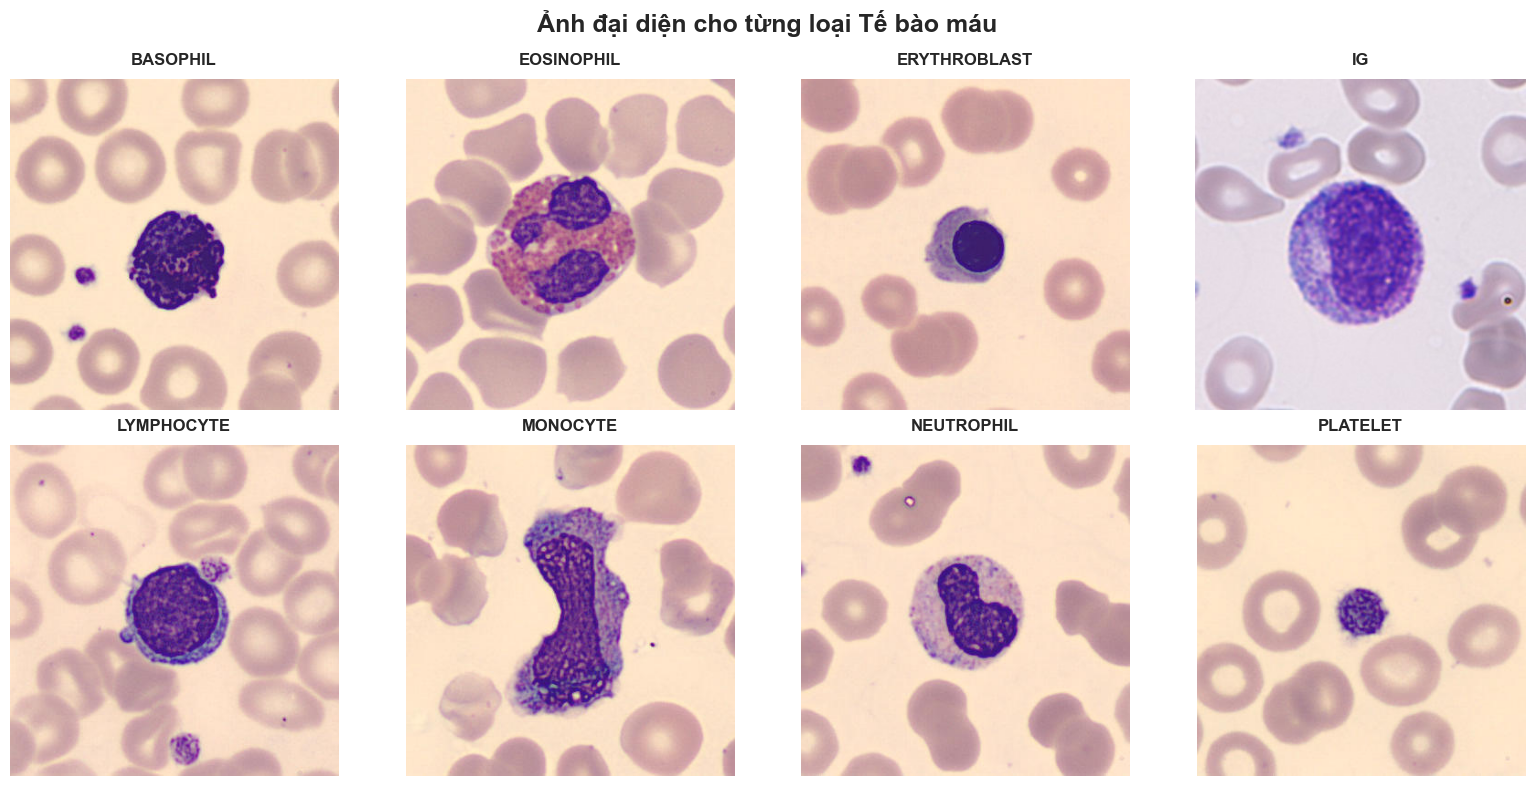

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten() 

for i, cls in enumerate(class_names):
    cls_path = os.path.join(data_dir, cls)
    image_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if image_files:
        # Lấy ảnh ĐẦU TIÊN làm đại diện
        rep_image_name = image_files[0] 
        img_path = os.path.join(cls_path, rep_image_name)        
        img = Image.open(img_path)
        axes[i].imshow(img)

        axes[i].set_title(f"{cls.upper()}", fontsize=12, fontweight='bold', pad=10)    
    axes[i].axis('off')
plt.suptitle('Ảnh đại diện cho từng loại Tế bào máu', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Đếm số lượng lớp
print(f"Tổng số lớp: {len(class_names)}")

# Đếm số lượng ảnh
data_counts = []
for cls in class_names:
    cls_path = os.path.join(data_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    data_counts.append({'Class': cls, 'Count': len(images)})
df_counts = pd.DataFrame(data_counts)
df_counts['Percentage (%)'] = round((df_counts['Count'] / df_counts['Count'].sum()) * 100, 2)

# Bảng thống kê số lượng ảnh theo lớp
display(df_counts)
print(f"Tổng cộng toàn bộ dataset: {df_counts['Count'].sum()} ảnh")

Tổng số lớp: 8


,Class,Count,Percentage (%)
0,basophil,1218,7.13
1,eosinophil,3117,18.24
2,erythroblast,1551,9.07
3,ig,2895,16.94
4,lymphocyte,1214,7.10
5,monocyte,1420,8.31
6,neutrophil,3329,19.48
7,platelet,2348,13.74


Tổng cộng toàn bộ dataset: 17092 ảnh


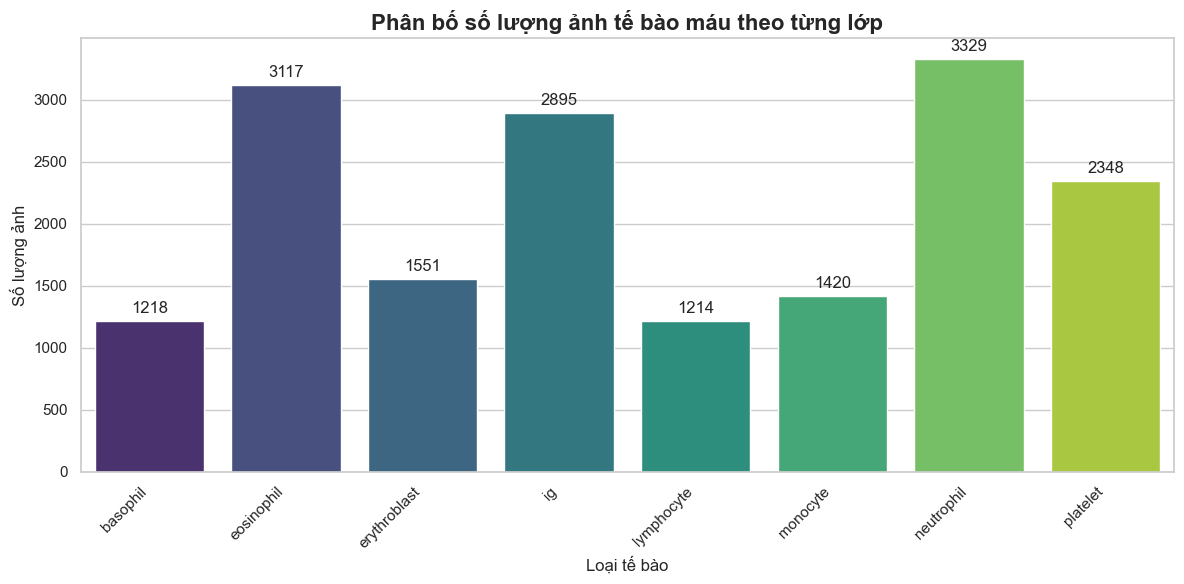

In [17]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Class', y='Count', data=df_counts, hue='Class', palette='viridis', legend=False)

plt.title('Phân bố số lượng ảnh tế bào máu theo từng lớp', fontsize=16, fontweight='bold')
plt.xlabel('Loại tế bào', fontsize=12)
plt.ylabel('Số lượng ảnh', fontsize=12)
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

100%|██████████| 17092/17092 [01:49<00:00, 156.66it/s]


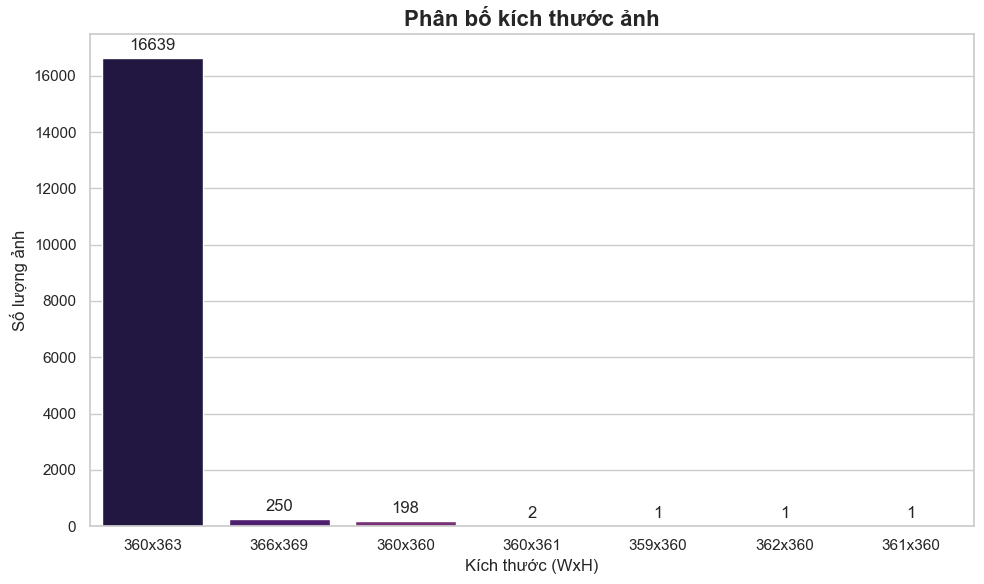


--- Thống kê Kích thước ---
- Kích thước 360x363: 16639 ảnh
- Kích thước 366x369: 250 ảnh
- Kích thước 360x360: 198 ảnh
- Kích thước 360x361: 2 ảnh
- Kích thước 359x360: 1 ảnh
- Kích thước 362x360: 1 ảnh
- Kích thước 361x360: 1 ảnh


In [24]:
all_image_paths = []
for cls in class_names:
    cls_path = os.path.join(data_dir, cls)
    all_image_paths.extend([os.path.join(cls_path, f) for f in os.listdir(cls_path) if f.endswith('.jpg')])

sample_paths = random.sample(all_image_paths, len(all_image_paths))

dimension_strings = []

for img_path in tqdm(sample_paths):
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            dimension_strings.append(f"{w}x{h}")
    except Exception as e:
        print(f"Lỗi đọc file {img_path}: {e}")

# Đếm số lượng ảnh cho mỗi loại kích thước
dim_counts = collections.Counter(dimension_strings)

df_dims = pd.DataFrame(dim_counts.items(), columns=['Kích thước (WxH)', 'Số lượng ảnh'])
df_dims = df_dims.sort_values(by='Số lượng ảnh', ascending=False) 

# Vẽ biểu đồ Cột
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Kích thước (WxH)', y='Số lượng ảnh', data=df_dims, hue='Kích thước (WxH)', palette='magma', legend=False)
plt.title('Phân bố kích thước ảnh', fontsize=16, fontweight='bold')
plt.xlabel('Kích thước (WxH)', fontsize=12)
plt.ylabel('Số lượng ảnh', fontsize=12)

# Thêm nhãn số lượng cụ thể trên mỗi cột
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

print("\n--- Thống kê Kích thước ---")
for index, row in df_dims.iterrows():
    print(f"- Kích thước {row['Kích thước (WxH)']}: {row['Số lượng ảnh']} ảnh")